# Rede Neural (MLP) para a função lógica XOR com PyTorch

### Isaac Kosloski Oliveira

**Disciplina:** Teoria e Aplicações de Inteligência Computacional I — Unidade 1, Aula 3

**Objetivo:** Implementar, em PyTorch, uma Rede Neural Artificial (MLP) capaz de aprender a
função lógica XOR por meio do processo de treinamento.

O XOR é o exemplo clássico de problema não linearmente separável: um único perceptron
não consegue resolvê-lo, sendo necessária pelo menos uma camada oculta com função de
ativação não linear.

**Conjunto de Dados**

| Entrada 1 | Entrada 2 | Saída |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

A implementação segue a estrutura apresentada na Aula 3, Capítulo 5.

## 1. Importação das Bibliotecas

In [1]:
import torch                                    # Biblioteca principal do PyTorch (tensores e autograd)
import torch.nn as nn                           # Módulo para construção de redes (camadas, ativações, perdas)
import torch.optim as optim                     # Algoritmos de otimização (SGD, Adam) para atualização dos pesos
from torch.utils.data import TensorDataset, DataLoader  # Utilitários para organizar dados em batches
import matplotlib.pyplot as plt                 # Visualização do gráfico da Loss


## 2. Hiperparâmetros

Valores definidos para o problema, conforme a Aula 3.

| Hiperparâmetro           | Valor |
|--------------------------|---|
| Learning Rate ($\eta$)   | 0.001 |
| Número de épocas         | 10000 (com Early Stopping) |
| Batch Size               | 1 (Gradiente Descendente Estocástico) |
| Otimizador               | SGD (momentum = 0.8, weight_decay = 1e-4) |
| Função de perda          | MSELoss (Erro Quadrático Médio) |
| Ativação (camada oculta) | ReLU |
| Ativação (saída)         | Sigmoid |

In [2]:
LEARNING_RATE = 0.001     # Taxa de aprendizado (eta): tamanho do passo na descida do gradiente
EPOCHS        = 10000     # Número máximo de épocas de treinamento
BATCH_SIZE    = 1         # 1 = SGD | intermediário = Mini-Batch | total (4) = Batch GD
HIDDEN_LAYERS = 1         # Número de camadas ocultas
NEURONS       = 3         # Neurônios por camada oculta
ACTIVATION    = "relu"    # relu | sigmoid | tanh  (ativação da(s) camada(s) oculta(s))
OPTIMIZER     = "SGD"     # SGD | Adam
MOMENTUM      = 0.8        # Termo de momento: acumula gradientes passados para acelerar a convergência
WEIGHT_DECAY  = 0.0001     # Regularização L2 (penaliza pesos grandes, evita overfitting)
DROPOUT       = 0          # Fração de neurônios desativados por passo (0 = desligado)
EARLY_STOPPING = True      # Interrompe o treino se a Loss parar de melhorar
PATIENCE      = 100        # Nº de épocas sem melhora toleradas antes de parar

## 3. Base de dados XOR

Construímos os tensores de entrada (`X`) e saída (`y`) diretamente da tabela verdade,
usando `torch.tensor`. Usamos `float` porque a rede trabalha com valores contínuos.

In [3]:
# BASE XOR (provinda da tabela verdade)
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],   # 0 XOR 0 = 0
    [1.],   # 0 XOR 1 = 1
    [1.],   # 1 XOR 0 = 1
    [0.]    # 1 XOR 1 = 0
])

print("Entradas (X):\n", X)
print("Saídas  (y):\n", y)

Entradas (X):
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
Saídas  (y):
 tensor([[0.],
        [1.],
        [1.],
        [0.]])


## 4. Dataset e DataLoader

`TensorDataset` agrupa `X` e `y` em pares indexados. O `DataLoader` itera sobre esses pares
em batches (aqui, tamanho 1) e embaralha (`shuffle=True`) a cada época.

In [4]:
dataset = TensorDataset(X, y)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Total de amostras: {len(dataset)} | Batches por época: {len(loader)}")

Total de amostras: 4 | Batches por época: 4


## 5. Escolha da função de ativação


In [5]:
if ACTIVATION.lower() == "relu":
    activation = nn.ReLU()
elif ACTIVATION.lower() == "sigmoid":
    activation = nn.Sigmoid()
elif ACTIVATION.lower() == "tanh":
    activation = nn.Tanh()
else:
    raise ValueError("Função de ativação inválida.")

print("Ativação da camada oculta:", activation)

Ativação da camada oculta: ReLU()


## 6. Construção da rede neural (MLP)

In [6]:
layers = []                                   # lista que armazenará as camadas em sequência

# Primeira camada: 2 entradas -> NEURONS
layers.append(nn.Linear(2, NEURONS))
layers.append(activation)

if DROPOUT > 0:
    layers.append(nn.Dropout(DROPOUT))        # regularização opcional

# Camadas ocultas adicionais (a primeira já foi criada, por isso HIDDEN_LAYERS - 1)
for _ in range(HIDDEN_LAYERS - 1):
    layers.append(nn.Linear(NEURONS, NEURONS))
    layers.append(activation)
    if DROPOUT > 0:
        layers.append(nn.Dropout(DROPOUT))

# Camada de saída: NEURONS -> 1, seguida de Sigmoid
layers.append(nn.Linear(NEURONS, 1))
layers.append(nn.Sigmoid())

# nn.Sequential aplica as camadas uma após a outra no forward pass
model = nn.Sequential(*layers)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)


## 7. Função de perda e otimizador

- **Perda:** `MSELoss` (Erro Quadrático Médio)
- **Otimizador:** `SGD` com `momentum` (acelera a convergência) e `weight_decay` (L2).

In [7]:
# FUNÇÃO DE PERDA
criterion = nn.MSELoss()

# OTIMIZADOR
if OPTIMIZER.upper() == "SGD":
    optimizer = optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )
elif OPTIMIZER.upper() == "ADAM":
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
else:
    raise ValueError("Otimizador inválido. Use 'SGD' ou 'Adam'.")

print("Perda:", criterion)
print("Otimizador:", optimizer)

Perda: MSELoss()
Otimizador: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.8
    nesterov: False
    weight_decay: 0.0001
)


## 8. Loop de treinamento

Para cada época: colocamos a rede em modo treino, iteramos sobre os batches e, em cada um,
executamos os cinco passos fundamentais do PyTorch:

1. `optimizer.zero_grad()`: zera gradientes acumulados;
2. `model(batch_x)`: **forward pass**;
3. `criterion(...)`: calcula a **Loss**;
4. `loss.backward()`: **backpropagation** (Autograd);
5. `optimizer.step()`: atualiza pesos e bias.

Ao final de cada época guardamos a Loss média e aplicamos o **Early Stopping**.

In [8]:
# Controle do treino
loss_history = []                 # Loss média por época (para o gráfico)
best_loss = float("inf")          # menor Loss já observada (Early Stopping)
counter   = 0                     # épocas consecutivas sem melhora

print("Iniciando treinamento...\n")

for epoch in range(EPOCHS):
    model.train()                 # modo treino (ativa Dropout/BatchNorm, se houver)
    epoch_loss = 0                # acumulador da Loss da época

    for batch_x, batch_y in loader:
        optimizer.zero_grad()             # 1) zera gradientes
        prediction = model(batch_x)       # 2) forward pass
        loss = criterion(prediction, batch_y)  # 3) calcula a Loss
        loss.backward()                   # 4) backpropagation (Autograd)
        optimizer.step()                  # 5) atualiza os pesos
        epoch_loss += loss.item()         # acumula a Loss do batch

    epoch_loss /= len(loader)             # Loss média da época
    loss_history.append(epoch_loss)       # armazena para o gráfico

    if (epoch + 1) % 500 == 0:
        print(f"Época: {epoch+1:5d} | Loss = {epoch_loss:.6f}")

    # EARLY STOPPING
    if EARLY_STOPPING:
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            counter = 0
        else:
            counter += 1
        if counter >= PATIENCE:
            print(f"\nEarly Stopping ativado. Treinamento encerrado na época {epoch+1}.")
            break

print("\nTreinamento concluído.")

Iniciando treinamento...

Época:   500 | Loss = 0.248243
Época:  1000 | Loss = 0.243580
Época:  1500 | Loss = 0.237507
Época:  2000 | Loss = 0.227614
Época:  2500 | Loss = 0.214009
Época:  3000 | Loss = 0.199607
Época:  3500 | Loss = 0.188047
Época:  4000 | Loss = 0.180300
Época:  4500 | Loss = 0.175609
Época:  5000 | Loss = 0.172796
Época:  5500 | Loss = 0.171072
Época:  6000 | Loss = 0.169974
Época:  6500 | Loss = 0.169269
Época:  7000 | Loss = 0.168766
Época:  7500 | Loss = 0.168407
Época:  8000 | Loss = 0.168153
Época:  8500 | Loss = 0.167924
Época:  9000 | Loss = 0.167792
Época:  9500 | Loss = 0.167669
Época: 10000 | Loss = 0.167555

Treinamento concluído.


## 9. Avaliação da rede

Colocamos a rede em modo de avaliação (`model.eval()`), desativamos o cálculo de gradientes
(`torch.no_grad()`) e verificamos a previsão para as quatro combinações do XOR.

O limiar de decisão é 0.5:

saída ≥ 0.5 → classe 1;

caso contrário → classe 0.

In [9]:
# TESTE DA REDE
print("RESULTADOS\n")

model.eval()                          # modo avaliação
with torch.no_grad():                 # sem cálculo de gradientes (inferência)
    output = model(X)

acertos = 0
print("Entrada  -> Esperada | Predita (classe)")
for entrada, esperado, previsto in zip(X, y, output):
    classe = 1 if previsto.item() >= 0.5 else 0
    ok = "OK" if classe == int(esperado.item()) else "X"
    acertos += (classe == int(esperado.item()))
    print(f"{entrada.numpy()} ->    {int(esperado.item())}     |  {previsto.item():.4f}  ({classe})  {ok}")

print(f"\nAcurácia: {acertos}/4 = {100*acertos/4:.0f}%")

RESULTADOS

Entrada  -> Esperada | Predita (classe)
[0. 0.] ->    0     |  0.0582  (0)  OK
[0. 1.] ->    1     |  0.6611  (1)  OK
[1. 0.] ->    1     |  0.6611  (1)  OK
[1. 1.] ->    0     |  0.6611  (1)  X

Acurácia: 3/4 = 75%


## 10. Gráfico da curva de aprendizado

A curva da Loss ao longo das épocas permite diagnosticar o treinamento: uma curva
decrescente indica aprendizado; uma curva que estabiliza indica convergência (ou Early
Stopping); oscilações fortes podem indicar taxa de aprendizado alta demais.

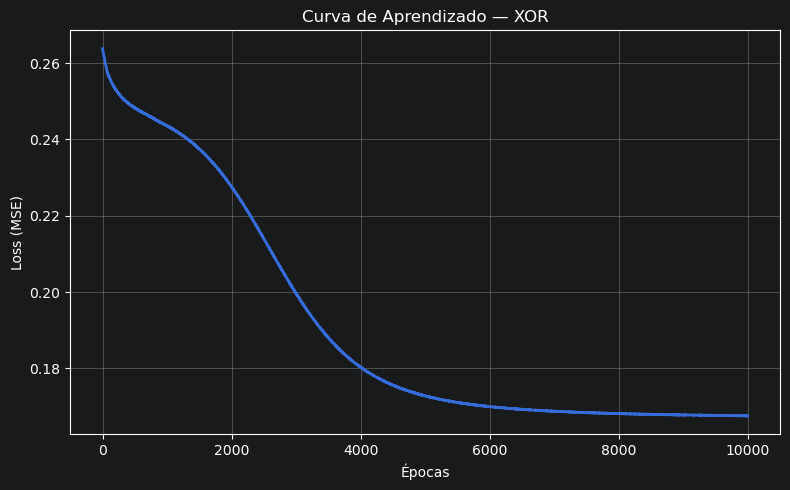

Loss inicial: 0.2638 | Loss final: 0.1676


In [10]:
# GRÁFICO DA CURVA DE APRENDIZADO
plt.figure(figsize=(8, 5))
plt.plot(loss_history, linewidth=2)
plt.title("Curva de Aprendizado — XOR")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.tight_layout()
plt.savefig("curva_aprendizado.png", dpi=120)   # salva a figura para entrega
plt.show()

print(f"Loss inicial: {loss_history[0]:.4f} | Loss final: {loss_history[-1]:.4f}")